In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Set style
sns.set_theme(style="whitegrid")

### 1. Load and Preprocess Data

Replicating the preprocessing steps from `main.ipynb` but removing target variables before PCA.

In [2]:
# Load the dataset
full_dataset = pd.read_csv("dataset.csv")
full_dataset = full_dataset.dropna()

# Filter to students
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)

# Drop unnecessary variables
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])

# Remove "Others"
dataset = dataset[dataset["Sleep Duration"] != "Others"].copy()
dataset = dataset[dataset["Dietary Habits"] != "Others"].copy()
sleep_mapping = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}

# Add interaction terms (as in main.ipynb)
dataset["Pressure_x_Sleep"] = dataset["Academic Pressure"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Stress"] = dataset["Academic Pressure"] * dataset["Financial Stress"]
dataset["Stress_x_Sleep"] = dataset["Financial Stress"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Satisfaction"] = dataset["Academic Pressure"] * dataset["Study Satisfaction"]

interaction_terms = ["Pressure_x_Sleep", "Pressure_x_Stress", "Stress_x_Sleep", "Pressure_x_Satisfaction"]

# Separate our targets
y_depression = dataset['Depression']
y_suicidal = dataset['Have you ever had suicidal thoughts ?']

# Features for PCA
X = dataset.drop(columns=['Depression', 'Have you ever had suicidal thoughts ?'])

# Define features
numeric_features = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress'
] + interaction_terms
categorical_features = [
    'Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Family History of Mental Illness'
]

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print(f"Processed feature matrix shape: {X_processed.shape}")

Processed feature matrix shape: (27837, 44)


### 2. Apply Principal Component Analysis (PCA)

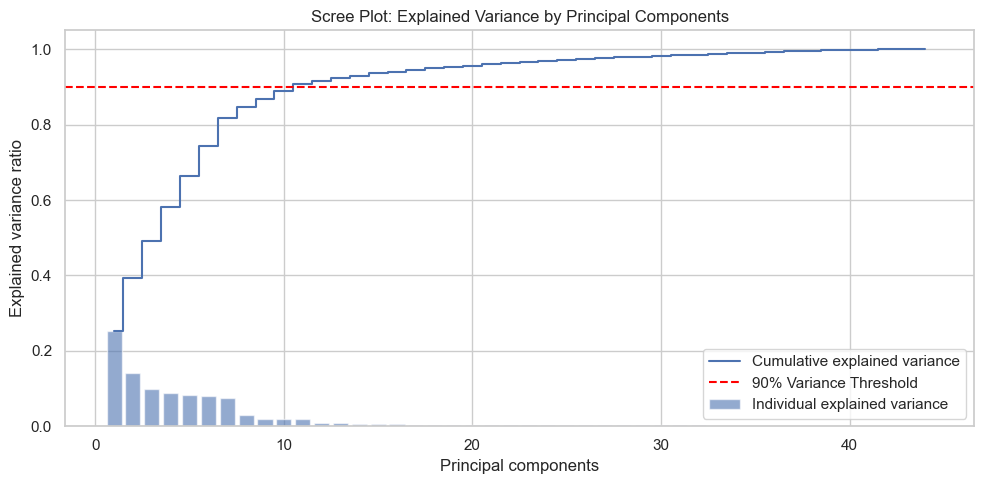

In [3]:
# Initialize and fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_processed)

# Calculate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot Explained Variance
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.axhline(max(cumulative_variance) * 0.90, color="red", linestyle="--", label="90% Variance Threshold")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### 3. Visualizing the 2D PCA Space

Plot the first two principal components and color the dots by Depression status to see if natural clustering or separation exists.

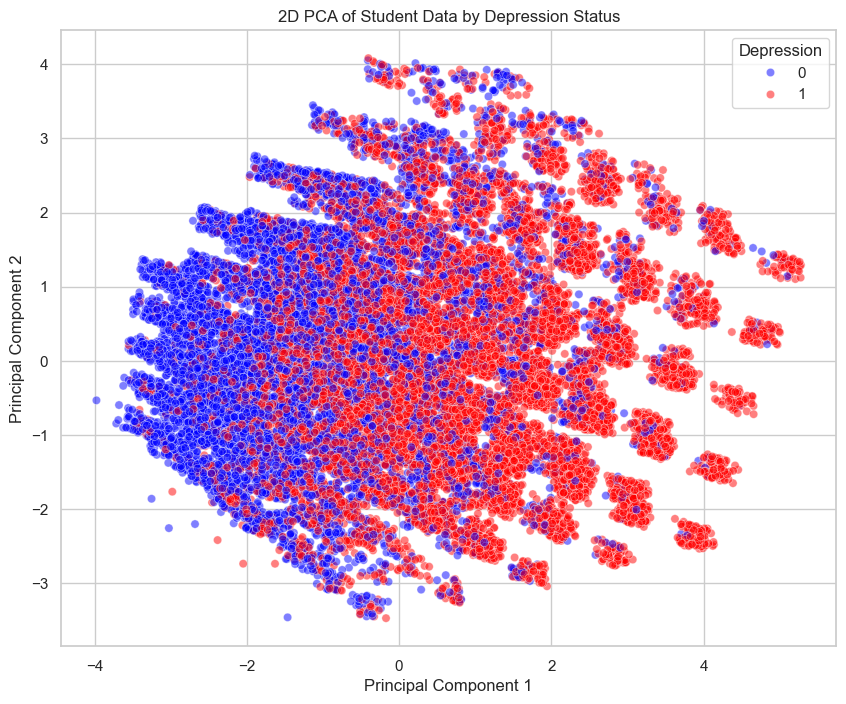

In [4]:
# Create a DataFrame with the first two PCs
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['Principal Component 1', 'Principal Component 2'])
# Add targets back in for visualization
pca_df['Depression'] = y_depression.values

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2',
    hue='Depression',
    palette={0: 'blue', 1: 'red'},
    data=pca_df,
    alpha=0.5
)
plt.title('2D PCA of Student Data by Depression Status')
plt.show()

### 4. PCA Component Loadings

What features make up Principal Component 1 and 2?

In [5]:
# Get the feature loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_.T[:, :2], columns=['PC1', 'PC2'], index=feature_names)

print("--- Top 5 Positive Contributors to PC1 ---")
print(loadings.sort_values(by='PC1', ascending=False)['PC1'].head(5))
print()
print("--- Top 5 Negative Contributors to PC1 ---")
print(loadings.sort_values(by='PC1', ascending=True)['PC1'].head(5))
print()

print("--- Top 5 Positive Contributors to PC2 ---")
print(loadings.sort_values(by='PC2', ascending=False)['PC2'].head(5))
print()
print("--- Top 5 Negative Contributors to PC2 ---")
print(loadings.sort_values(by='PC2', ascending=True)['PC2'].head(5))


--- Top 5 Positive Contributors to PC1 ---
num__Pressure_x_Stress    0.505540
num__Academic Pressure    0.429438
num__Pressure_x_Sleep     0.419754
num__Stress_x_Sleep       0.362812
num__Financial Stress     0.354637
Name: PC1, dtype: float64

--- Top 5 Negative Contributors to PC1 ---
num__Age                                -0.092028
cat__Sleep Duration_Less than 5 hours   -0.062685
num__CGPA                               -0.017567
cat__Dietary Habits_Moderate            -0.015014
cat__Gender_Male                        -0.006846
Name: PC1, dtype: float64

--- Top 5 Positive Contributors to PC2 ---
num__Pressure_x_Satisfaction             0.595328
num__Study Satisfaction                  0.545921
num__Academic Pressure                   0.232463
cat__Sleep Duration_Less than 5 hours    0.056803
num__Pressure_x_Sleep                    0.051490
Name: PC2, dtype: float64

--- Top 5 Negative Contributors to PC2 ---
num__Financial Stress                   -0.366483
num__Stress_x_Sleep   

### 5. Conclusions & Summary

Based on the PCA Feature Loadings extracted above, these are some insight regarding the factors driving the variance in the student dataset:

#### 1. Principal Component 1 (PC1): The Compounded Stress Index
The first principal component, which captures the vast majority of the variance in the data, is overwhelmingly driven by **Academic Pressure**, **Financial Stress**, and the engineered interaction terms (`Pressure_x_Stress`, `Pressure_x_Sleep`). 
*   **Conclusion:** The single biggest differentiator between students in this dataset is their compounded stress level. The custom interaction features I engineered are highly significant and dominate the variance, while demographic and minor lifestyle categories (such as Gender or Dietary Habits) have negligible impact on this primary axis.

#### 2. Principal Component 2 (PC2): Academic Engagement vs. Financial Burden
The second principal component distinguishes between different sources of stress. Its highest positive contributors are `Study Satisfaction` and its interaction with pressure (`Pressure_x_Satisfaction`), while its highest negative contributors are `Financial Stress` and its interactions.
*   **Conclusion:** This axis effectively separates students who are highly engaged and satisfied with their studies (despite facing academic pressure) from those who are primarily burdened by significant financial stress.

#### Final Takeaways for Predicting Depression:
1.  **Efficacy of Feature Engineering:** The custom interaction terms I developed (e.g., `Pressure_x_Stress`) proved to be mathematically the most important elements in explaining the dataset's variance. 
2.  **Categorical Variables as Noise:** Categorical features such as Sleep Duration, Diet, and Gender load very poorly onto the primary components, suggesting they contribute more noise than signal compared to the continuous stress variables.
3.  **Modeling Strategy:** Because the continuous stress and pressure variables completely drive the underlying structure of the data, classification models such as **LDA** and **QDA** are expected to perform exceptionally well given their reliance on well-defined mathematical separations (which PC1 and PC2 clearly represent).
